
RQ5 Model Rankings:

          Model  Rank_Accuracy  Rank_Recall  Rank_F1  Rank_AUC
0      Logistic              4            1        1         1
1  RandomForest              1            3        3         3
2           SVM              3            2        2         4
3       XGBoost              2            4        4         2


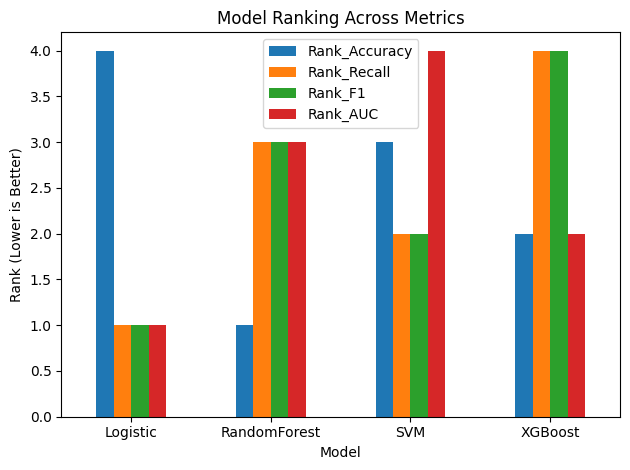

In [10]:
# RQ5: MODEL RANKING

import pandas as pd
import matplotlib.pyplot as plt

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, recall_score, f1_score, roc_auc_score


# LOAD DATASET

df = pd.read_csv('/kaggle/input/datasets/uom190346a/synthetic-clinical-tabular-dataset/synthetic_clinical_dataset.csv')
df = df.dropna()

# DEFINE X and y

y = df['mortality']
X = df.drop(columns=['mortality'])

# PREPROCESSING

numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = X.select_dtypes(include=['object']).columns

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
])


# SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# MODELS 

models = {
    'Logistic': Pipeline([
        ('preprocessor', preprocessor),
        ('model', LogisticRegression(max_iter=3000, class_weight='balanced'))
    ]),
    
    'RandomForest': Pipeline([
        ('preprocessor', preprocessor),
        ('model', RandomForestClassifier(class_weight='balanced', random_state=42))
    ]),
    
    'SVM': Pipeline([
        ('preprocessor', preprocessor),
        ('model', SVC(probability=True, class_weight='balanced'))
    ]),

    'XGBoost': Pipeline([
        ('preprocessor', preprocessor),
        ('model', XGBClassifier(eval_metric='logloss'))
    ])
}

# COMPUTE RESULTS 

results = []

for name, model in models.items():
    model.fit(X_train, y_train)

    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = model.predict(X_test)

    results.append([
        name,
        accuracy_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred),
        roc_auc_score(y_test, y_prob)
    ])

results_df = pd.DataFrame(results, columns=[
    'Model','Accuracy','Recall','F1','AUC'
])

# RANKING

rank_df = results_df.copy()

rank_df['Rank_Accuracy'] = rank_df['Accuracy'].rank(ascending=False, method='first')
rank_df['Rank_Recall']   = rank_df['Recall'].rank(ascending=False, method='first')
rank_df['Rank_F1']       = rank_df['F1'].rank(ascending=False, method='first')
rank_df['Rank_AUC']      = rank_df['AUC'].rank(ascending=False, method='first')

rank_df[['Rank_Accuracy','Rank_Recall','Rank_F1','Rank_AUC']] = \
rank_df[['Rank_Accuracy','Rank_Recall','Rank_F1','Rank_AUC']].astype(int)

print("\nRQ5 Model Rankings:\n")
print(rank_df[['Model','Rank_Accuracy','Rank_Recall','Rank_F1','Rank_AUC']])

# SAVE TABLE

rank_df.to_csv("rq5_ranking.csv", index=False)

rank_df.set_index('Model')[['Rank_Accuracy','Rank_Recall','Rank_F1','Rank_AUC']].plot(kind='bar')

plt.title("Model Ranking Across Metrics")
plt.ylabel("Rank (Lower is Better)")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig("rq5_ranking_plot.pdf")
plt.show()